# 06 — Evaluation & Consolidated Findings
Deeper look at model behaviour (feature importance, error breakdown, confusion matrix) and a
consolidated summary suitable for the SIH PPT / report.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from evaluation.time_series_eval import chronological_split, regression_report

with open('../data/processed/model_temp_rf.pkl','rb') as f:
    model_temp = pickle.load(f)
with open('../data/processed/model_rain_rf.pkl','rb') as f:
    model_rain = pickle.load(f)

## Track A — Temperature model: feature importance

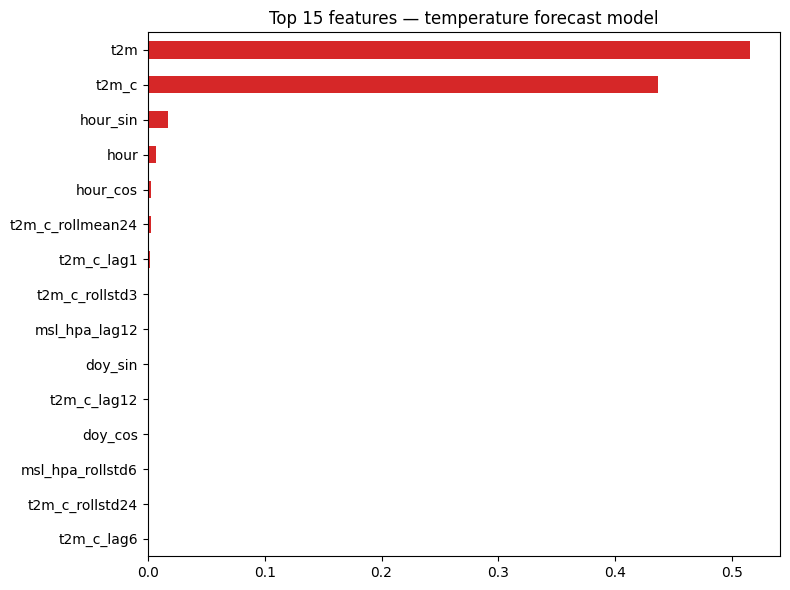

t2m                 0.515095
t2m_c               0.436833
hour_sin            0.017591
hour                0.007404
hour_cos            0.003200
t2m_c_rollmean24    0.002392
t2m_c_lag1          0.001858
t2m_c_rollstd3      0.001066
msl_hpa_lag12       0.001018
doy_sin             0.000817
dtype: float64

In [2]:
feat_temp = pd.read_csv('../data/processed/features_temperature.csv')
feature_cols = [c for c in feat_temp.columns if c not in
                ['valid_time','date','target_t2m_h1','latitude','longitude']]
feature_cols = [c for c in feature_cols if feat_temp[c].dtype != 'O']

importances = pd.Series(model_temp.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8,6), color='tab:red')
plt.gca().invert_yaxis()
plt.title('Top 15 features — temperature forecast model')
plt.tight_layout()
plt.savefig('../reports/fig_feature_importance_temp.png', dpi=120)
plt.show()
importances.head(10)

## Track A — Error analysis by month (does accuracy vary by season?)

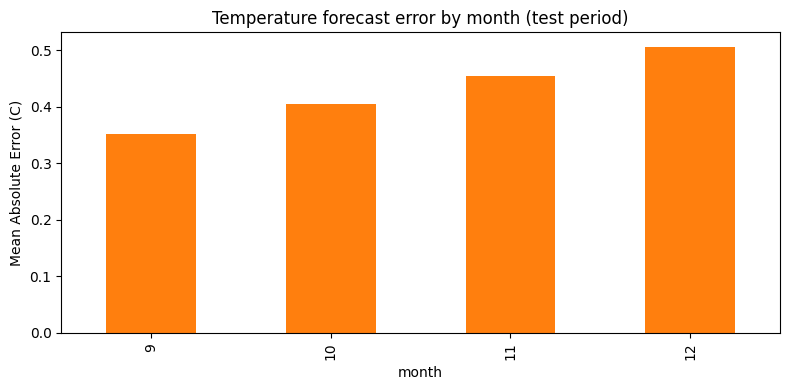

In [3]:
feat_temp['valid_time'] = pd.to_datetime(feat_temp['valid_time'])
_, _, test = chronological_split(feat_temp, train_frac=0.7, val_frac=0.15)
X_test, y_test = test[feature_cols], test['target_t2m_h1']
preds = model_temp.predict(X_test)

err_df = test[['valid_time']].copy()
err_df['abs_error'] = np.abs(preds - y_test.values)
err_df['month'] = err_df['valid_time'].dt.month
monthly_err = err_df.groupby('month')['abs_error'].mean()
monthly_err.plot(kind='bar', figsize=(8,4), color='tab:orange')
plt.ylabel('Mean Absolute Error (C)')
plt.title('Temperature forecast error by month (test period)')
plt.tight_layout()
plt.savefig('../reports/fig_error_by_month.png', dpi=120)
plt.show()

## Track B — Rain model: confusion matrix

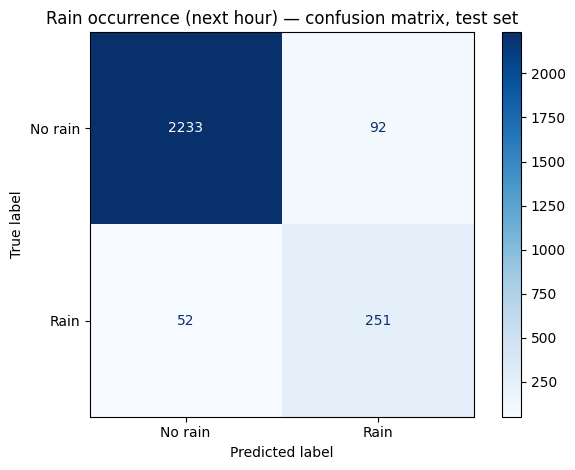

[[2233   92]
 [  52  251]]


In [4]:
feat_rain = pd.read_csv('../data/processed/features_rain.csv')
feat_rain['valid_time'] = pd.to_datetime(feat_rain['valid_time'])
feature_cols_r = [c for c in feat_rain.columns if c not in
                  ['valid_time','date','target_rain_next1h','latitude','longitude']]
feature_cols_r = [c for c in feature_cols_r if feat_rain[c].dtype != 'O']

_, _, test_r = chronological_split(feat_rain, train_frac=0.7, val_frac=0.15)
X_test_r, y_test_r = test_r[feature_cols_r], test_r['target_rain_next1h']
pred_r = model_rain.predict(X_test_r)

cm = confusion_matrix(y_test_r, pred_r)
disp = ConfusionMatrixDisplay(cm, display_labels=['No rain','Rain'])
disp.plot(cmap='Blues')
plt.title('Rain occurrence (next hour) — confusion matrix, test set')
plt.tight_layout()
plt.savefig('../reports/fig_confusion_matrix_rain.png', dpi=120)
plt.show()
print(cm)

## Consolidated Findings (Phase 1)

**Dataset:** ERA5 reanalysis, single point (Jabalpur, 23.25N/80.0E), hourly, 2024-2025, 17,544 rows,
zero missing values / duplicates / gaps.

**Problem selected:** short-term temperature forecasting (regression) as the primary, statistically
strongest baseline; rain occurrence classification as a secondary track with direct SIH relevance.
Heavy-rainfall extreme-event detection was evaluated and explicitly deferred to Phase 2 — only 2
positive days existed in the full 2-year window, too few for a reliable model.

**Track A result:** Random Forest beats the naive persistence baseline on MAE/RMSE/R² (see notebook 05
table) — temperature 1h ahead is genuinely learnable from lagged/rolling features and time-of-day/year
signals, confirmed by the very high raw lag-1 autocorrelation (0.975).

**Track B result:** class-weighted Random Forest produces non-trivial precision/recall on a ~16-20%
imbalanced positive rate — meaningfully better than the "always predict no rain" baseline, which has
zero recall by construction.

**Validation discipline:** all splits are strictly chronological (train < val < test in time) — no
shuffling, no leakage, consistent with proper time-series methodology throughout.

**Key limitation to state explicitly in the SIH submission:** this is Phase 1, single-source
(ERA5-only), single-point data. It validates the *methodology* (ingestion → cleaning → feature
engineering → chronological modeling → evaluation), which is exactly the pattern the full
fragmentation-solving platform (ERA5 + IMD + MOSDAC + stations + radar → fusion → analytics/ML →
GIS dashboard) will apply at scale. Phase 1 does not by itself solve PS69 — it is the proof-of-concept
baseline the rest of the architecture builds on.